# ConvAcc — Device Demo

This notebook is a **hands-on demo** of the `convAcc` 2D convolution accelerator
running on a PYNQ-Z2 board (Xilinx Zynq-7000 SoC). It walks through three
progressively more interesting use-cases:

1. **Greyscale image** — the canonical end-to-end flow for a single 60×60 image.
2. **Color image** — the same flow run three times (one per R/G/B channel).
3. **Large image** — a tiling strategy that lets a 60-wide accelerator handle
   images much wider than 60 pixels, plus a head-to-head **timing comparison**
   against scipy on the on-chip Arm Cortex-A9.

### What the accelerator does
`convAcc` performs a **3×3 valid-mode 2D convolution** with **8-bit unsigned pixels**
and **9-bit signed kernel coefficients**, returning **8-bit unsigned outputs
saturated to [0, 255]**. For an `H × W` input image, the output is `(H-2) × (W-2)`.

### How the host talks to it
Communication is **AXI-Stream only** (no AXI-Lite control registers). The host:

1. Loads a bitstream and grabs a handle to the AXI DMA.
2. Sends a 4-word **config packet** (image dims + kernel) followed by packed pixels.
3. Reads back the convolved pixels from the receive DMA channel.

### Hardware envelope to keep in mind
- Max image **width** the accelerator supports in one shot: **60 pixels**
  (the line-buffer is 4 lanes × 60 deep). For wider images, see the tiling
  example at the end.
- Max image **height**: 1023 rows (10-bit `num_rows` field in the config word).
- Clock: 125 MHz on the PL.

> **Prerequisites to run this notebook:** A PYNQ-Z2 board running the PYNQ
> image, the `convacc125.bit` bitstream + matching `.hwh` in the working
> directory, and the input images `flower_6060.jpg` and `Lenna.png`.


# Imports 

These are the imports will be used to load the images, prerocess and comaprision also.
The import will also include overlay instansation for the device DMA

### What each import is for

- `numpy` — image arrays and bit-twiddling on uint8/uint32 buffers.
- `pynq.Overlay` / `pynq.allocate` — load the bitstream and allocate
  **physically contiguous, DMA-accessible** memory (CMA buffers). Ordinary
  NumPy arrays will **not** work for DMA transfers.
- `struct` — used to convert the 32-bit receive words back into raw bytes
  in little-endian order so we can reshape them into an image.
- `matplotlib.pyplot` — show input / hardware output / software reference
  side-by-side.
- `scipy.signal.convolve2d` — the **golden reference** the hardware output
  is compared against.
- `pandas` — currently unused in this notebook, kept for any tabular logging
  you might want to add.
- `PIL.Image` — opens the source images from disk before they get converted
  to NumPy arrays.


In [29]:
import numpy as np
from pynq import Overlay, allocate
import struct
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import pandas as pd
from PIL import Image

## Loading the overlay and picking a kernel

`Overlay("convacc125.bit")` programs the FPGA fabric with the convAcc design.
PYNQ also reads the matching **`convacc125.hwh`** file (must sit next to the
`.bit`) to discover the IP blocks in the design — that's how `ol.axi_dma`
just works without any further configuration.

### About the bitstream filename
The filename suffix `125` reflects the **125 MHz** PL clock the design is
synthesized for. (Earlier revisions used a `100`-MHz-tagged filename; the
commented-out `convacc2d.bit` line is a leftover from an even older build.)

### About the kernel
The kernel is a plain Python `list` of 3 rows × 3 ints. Any integer in
`[-256, 255]` works — `build_config()` will clamp and 9-bit-encode it later.
Three example kernels are included; uncomment whichever you want to try:

- **Sobel-X** (commented): horizontal edge detector.
- **Embossing kernel** (active): produces a "raised" shaded look.
- **Identity** (commented): a sanity check — output should equal the input
  cropped by 1 pixel on each side.

> **Sanity check:** if `dma.sendchannel.running` or `recvchannel.running`
> reports anomalies on a fresh load, re-run this cell — it re-instantiates
> the DMA driver from a clean state.


In [30]:
# ol = Overlay("convacc2d.bit")
ol = Overlay("convacc125.bit")
dma = ol.axi_dma

print("Overlay loaded and DMA reset")
print(f"Send channel running: {dma.sendchannel.running}")
print(f"Recv channel running: {dma.recvchannel.running}")

# kernel = [
#     [1,  0, -1],
#     [2,  0, -2],
#     [1 , 0, -1],
# ]

kernel = [
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
]

# kernel = [
#     [0, 0,  0],
#     [0,  1,  0],
#     [ 0,  0,  0]
# ]

Overlay loaded and DMA reset
Send channel running: True
Recv channel running: True


## Helper functions — the on-the-wire protocol

Two tiny helpers do all the bit-packing the rest of the notebook needs.

### `to_signed9(v)` — encode a signed int as 9-bit two's-complement
The hardware MAC takes **9-bit signed** kernel coefficients. The expression
`v & 0x1FF` keeps only the low 9 bits, which is exactly the two's-complement
encoding the RTL expects (the hardware re-interprets bit 8 as the sign bit).
The clamp to `[-256, 255]` is just a guard against bad inputs.

### `build_config(row_width, num_rows, kernel)` — the 4-word config packet
Every transfer to the accelerator must start with **exactly 4 config words**:

| Word    | Bits  | Meaning                                  |
|---------|-------|------------------------------------------|
| `cfg0`  | `[5:0]`  | `row_width`  (image width, 1–63)      |
| `cfg0`  | `[15:6]` | `num_rows`   (image height, 1–1023)   |
| `cfg1`  | 27 bits  | row 0 of kernel: `k02 \| k01 \| k00` (each 9 b) |
| `cfg2`  | 27 bits  | row 1 of kernel                       |
| `cfg3`  | 27 bits  | row 2 of kernel                       |

These four words are consumed by `cf_mem` inside the IP, *not* re-sent down
the pixel pipeline.


### `pack_pixels(image)` — 4 bytes per AXI beat, row-major
The accelerator's slave interface is 32 bits wide, so 4 pixels go down the
wire per beat. `pack_pixels` flattens the image in row-major order, zero-pads
to a multiple of 4, and packs each group of 4 bytes little-endian into one
`uint32`.


In [31]:
# Helper encode a signed value as a 9-bit two's-complement integer
def to_signed9(v: int) -> int:
    v = max(-256, min(255, v))
    return v & 0x1FF      
 

# Build Config Packet (4 × 32-bit words)
def build_config(row_width: int, num_rows: int, kernel: list) -> list:
 
    assert 0 < row_width <= 64,  f"row_width {row_width} out of range [1,63]"
    assert 0 < num_rows  <= 1023, f"num_rows {num_rows} out of range [1,1023]"
 
    cfg0 = (row_width & 0x3F) | ((num_rows & 0x3FF) << 6)
 
    def pack_row(r):
        k0 = to_signed9(kernel[r][0])
        k1 = to_signed9(kernel[r][1])
        k2 = to_signed9(kernel[r][2])
        return k0 | (k1 << 9) | (k2 << 18)
 
    return [cfg0, pack_row(0), pack_row(1), pack_row(2)]
 
# Build Pixel Data (packed 4 bytes / 32-bit word, row-major)
def pack_pixels(image: np.ndarray) -> list:
    flat = image.flatten().astype(np.uint8)

    remainder = len(flat) % 4
    if remainder:
        flat = np.append(flat, np.zeros(4 - remainder, dtype=np.uint8))
    words = []
    for i in range(0, len(flat), 4):
        w = int(flat[i]) | (int(flat[i+1]) << 8) | (int(flat[i+2]) << 16) | (int(flat[i+3]) << 24)
        words.append(w)
    return words

# Greyscale image example
In this example one greyscale image will be convolouted with a kernel and explained on how its done. The same procedure applies for all other examples. 

## Step 1 — Load the input image

Open the JPEG, force it to single-channel greyscale (`"L"`), and convert
into a 2-D `uint8` NumPy array. `H, W` are then the image's height and width
in pixels — the values that will end up in the config packet.


In [32]:
# importing the image 
img6060Greyscale = Image.open("flower_6060.jpg")

# Converting the color image to black and white 
img6060Greyscale = img6060Greyscale.convert("L")

# making sure all the values are between 0-255
img6060Greyscale = np.array(img6060Greyscale, dtype=np.uint8)

#veriying the matrix is of 60X60 after all the operations 
H, W = img6060Greyscale.shape

## Step 2 — Build the config + pixel words

`cfg_words` is the 4-word header described above; `pixel_words` is the image
packed 4-bytes-per-word. Together they form the entire AXI-Stream payload
the accelerator will see for one frame.

The print-out is useful for debugging: if a config word looks wrong (e.g.
the dimensions field is zero, or a kernel value didn't sign-extend), you'll
spot it here before it becomes a "DMA hangs forever" mystery.


In [33]:
#Creating a cfg Packet using the helper
cfg_words = build_config(H, W, kernel)

#packing all the pixel values 4byes per beat
pixel_words = pack_pixels(img6060Greyscale)

print("\n Config Words (hex)")
for i, w in enumerate(cfg_words):
    print(f"  cfg[{i}] = 0x{w:08X}")
    
print(f"\n Pixel Words: {len(pixel_words)} 32-bit words ({H}×{W} = {H*W} bytes)")


 Config Words (hex)
  cfg[0] = 0x00000F3C
  cfg[1] = 0x0003FFFE
  cfg[2] = 0x000403FF
  cfg[3] = 0x00080200

 Pixel Words: 900 32-bit words (60×60 = 3600 bytes)


## Step 3 — Allocate DMA buffers and load the send buffer

Three things happen here:

1. **Concatenate** the 4 config words and the pixel words into one flat list
   of `uint32`s — this is the order they need to appear on the AXI-Stream.
2. **`pynq.allocate`** the send buffer. This is *not* an ordinary NumPy
   array — under the hood it's a CMA-backed region that the AXI DMA can
   read directly without going through the kernel page tables.
3. **Allocate the receive buffer.** The valid-mode output is `(H-2)×(W-2)`
   pixels, packed 4 per word. The `+ 8` slack just adds headroom so a
   slightly off-by-one estimate from the hardware never overruns the buffer.


In [34]:
# assembling the data and transfer channels
all_beats = cfg_words + pixel_words
n_words_in = len(all_beats)
n_bytes_in = n_words_in * 4

# Allocate contiguous DMA-accessible input buffer
send_buf = allocate(shape=(n_words_in,), dtype=np.uint32)

#loading data onto the send buffer. 
for i, w in enumerate(all_beats):
    send_buf[i] = w
    
# creating output buffer 
n_out_pixels = (H-2) * (W-2)                   
n_out_words  = (n_out_pixels + 3) // 4           
recv_buf = allocate(shape=(n_out_words + 8,), dtype=np.uint32)  

## Step 4 — Kick off the DMA transfers

**Order matters here.** The `convAcc` pipeline starts emitting result pixels
as soon as it has consumed the first three rows of input — it does **not**
wait for the whole frame to arrive. So the receive (S2MM) channel must be
**armed first**, otherwise the first results would be dropped on the floor:

```
recvchannel.transfer(recv_buf)   # arm S2MM first
sendchannel.transfer(send_buf)   # then push the frame in
```

The two `wait()` calls block until both DMAs report completion. After this
cell returns, `recv_buf` holds the convolved pixels.


In [35]:
# Actually sending the data to the Acclerator
dma.sendchannel.start()
dma.recvchannel.start()

# Start S2MM (receive) first since the design starts outputting data even before the image is over
dma.recvchannel.transfer(recv_buf)

# Start MM2S (send)
dma.sendchannel.transfer(send_buf)

dma.recvchannel.wait()
dma.sendchannel.wait()



## Step 5 — Unpack the result and build a software reference

The hardware returned `n_out_words` packed `uint32`s. To get an image back:

1. **Re-serialise** those words to little-endian bytes with `struct.pack('<I', …)`.
2. **Trim** to exactly `n_out_pixels` bytes (drop the zero-padding).
3. **Reshape** to `(H-2, W-2)` — valid-mode crops 1 pixel off each side.

The software reference uses `scipy.signal.convolve2d(..., mode='valid')`,
then **clips to `[0, 255]`** to match the hardware's saturate-on-overflow
behaviour. (Without the clip, scipy would return signed ints that don't
correspond to what the 8-bit output port can carry.)

### Free the buffers
`freebuffer()` releases the CMA region. The PYNQ kernel module has a finite
pool, so leaking buffers across many runs eventually causes `allocate()` to
fail. **Always free what you allocate.**


In [36]:
# # use this to check if the recv_buffer recieved data
# for i in recv_buf:
#     print(i)

# arranging the buffer into order to prepare for viewing
raw_bytes = bytearray()
for word in recv_buf[:n_out_words]:
    raw_bytes += struct.pack('<I', int(word))   # little-endian unpack
 
output_pixels = np.frombuffer(raw_bytes[:n_out_pixels], dtype=np.uint8)
output_image  = output_pixels.reshape(H-2, W-2)


#Creating a reference Image using the scipy library
ref_full   = convolve2d(img6060Greyscale.astype(np.int32), np.array(kernel, dtype=np.int32), mode='valid')
ref_output = np.clip(ref_full, 0, 255).astype(np.uint8)


# Free the buffer so it can be allocated for other work.
dma.sendchannel.stop()
dma.recvchannel.stop()
send_buf.freebuffer()
recv_buf.freebuffer()

## Step 6 — Visual + numeric verification

A 1×3 figure: the input, the hardware output, and the scipy reference. The
suptitle does the actual pass/fail check with `np.array_equal` — for the
embossing kernel and a typical photo this should be a **bit-exact match**
in green.

> If you ever see `FAIL`, the most common causes are:
> - Wrong kernel sign extension (check `cfg_words` print-out).
> - Wrong image dims passed to `build_config` (mind the `row_width` / `num_rows`
>   ordering noted above).
> - Forgetting to re-arm `recvchannel` before `sendchannel` on a re-run.


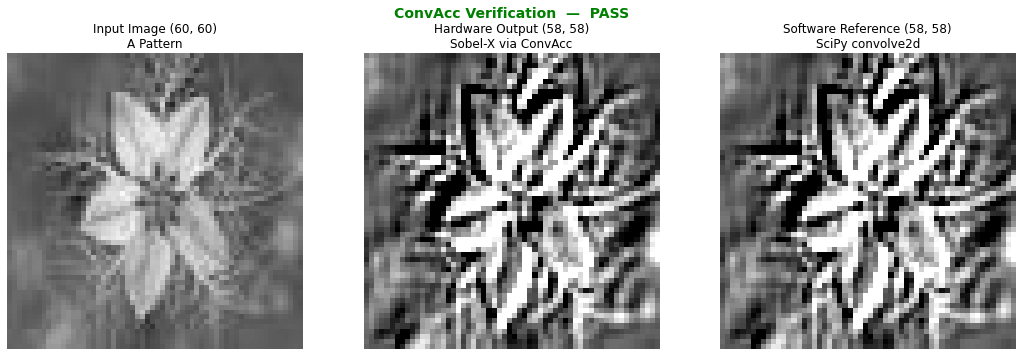

In [37]:
# Plotting the Original and results

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img6060Greyscale, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axes[0].set_title(f'Input Image {img6060Greyscale.shape}\nA Pattern', fontsize=12)
axes[0].axis('off')

axes[1].imshow(output_image, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axes[1].set_title(f'Hardware Output {output_image.shape}\nSobel-X via ConvAcc', fontsize=12)
axes[1].axis('off')

axes[2].imshow(ref_output, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axes[2].set_title(f'Software Reference {ref_output.shape}\nSciPy convolve2d', fontsize=12)
axes[2].axis('off')

match  = np.array_equal(output_image, ref_output)
n_diff = int(np.sum(output_image != ref_output))
fig.suptitle(
    f'ConvAcc Verification  —  {"PASS" if match else f"FAIL  ({n_diff}/676 pixels differ)"}',
    fontsize=14,
    fontweight='bold',
    color='green' if match else 'red'
)

plt.tight_layout()
# plt.savefig('convacc_output.png', dpi=150, bbox_inches='tight')
plt.show()

# Color Image Example
This will use the same steps as earlier but do 60x60 transactions 3 times for R, G, B resepctively.

## Color image — three channels, three transfers

`convAcc` only knows about a single 8-bit channel, so RGB is handled by
running the **same** convolution **three times** — once per colour plane —
and stacking the results. Splitting the image with NumPy fancy-indexing
(`img[:, :, 0]` etc.) gives three contiguous 60×60 `uint8` arrays.

> The config packet (`cfg_words`) and the image dimensions don't change
> across the three runs, so we deliberately reuse the same `cfg_words` from
> the greyscale section above — that's why we built it there with the
> intent of also using it here.


In [38]:
# importing the image 
img6060RGB = Image.open("flower_6060.jpg")

# making sure all the values are between 0-255
img6060RGB = np.array(img6060RGB, dtype=np.uint8)

#veriying the matrix is of 60X60 after all the operations 
H, W, C = img6060RGB.shape

R = img6060RGB[:, :, 0]  # shape (60, 60)
G = img6060RGB[:, :, 1]  # shape (60, 60)
B = img6060RGB[:, :, 2]  # shape (60, 60)

print(H,W,C)

60 60 3


## Pack all three channels and allocate the shared buffers

A small optimisation: rather than allocating fresh CMA buffers for each
channel, we allocate **one** `send_buf` / `recv_buf` pair sized for one
channel, and **rewrite** the contents three times (once per channel). This
keeps CMA pressure low and matches what a real streaming application would
do — preparing the next frame in-place while the DMA is busy with the
current one.

This cell also stages the **R-channel** payload into `send_buf`. The DMA
itself is launched in the next cell.


In [39]:
# packing the RGB Values seperately
in_R = pack_pixels(R)
in_G = pack_pixels(G)
in_B = pack_pixels(B)


# assembling the data and transfer channels
all_beats = cfg_words + in_R
n_words_in = len(all_beats)
n_bytes_in = n_words_in * 4

# Allocate contiguous DMA-accessible input buffer
send_buf = allocate(shape=(n_words_in,), dtype=np.uint32)

#loading data onto the send buffer. currently channel R 
for i, w in enumerate(all_beats):
    send_buf[i] = w
    
# creating output buffer 
n_out_pixels = (H-2) * (W-2)                   
n_out_words  = (n_out_pixels + 3) // 4           
recv_buf = allocate(shape=(n_out_words + 8,), dtype=np.uint32)  


## Run the R channel through the accelerator

Same launch sequence as the greyscale demo: arm S2MM, fire MM2S, wait for
both, then unpack the 32-bit words back into bytes and reshape to `(H-2, W-2)`.
After this cell, `output_image_R` holds the convolved red plane.


In [40]:
# for this Example We will re sue the same buffer in order fro all 3 transactions,
# instead of creating seperate buffers for each channel

# Channel R

# Actually sending the data to the Acclerator
dma.sendchannel.start()
dma.recvchannel.start()

# Start S2MM (receive) first since the design starts outputting data even before the image is over
dma.recvchannel.transfer(recv_buf)

# Start MM2S (send)
dma.sendchannel.transfer(send_buf)

dma.recvchannel.wait()
dma.sendchannel.wait()

# arranging the buffer into order to prepare for viewing
raw_bytes_R = bytearray()
for word in recv_buf[:n_out_words]:
    raw_bytes_R += struct.pack('<I', int(word))   # little-endian unpack
 
output_pixels_R = np.frombuffer(raw_bytes_R[:n_out_pixels], dtype=np.uint8)
output_image_R  = output_pixels_R.reshape(H-2, W-2)



## Run the G channel — buffer reuse in action

Notice three things this cell does **not** do:

- It **doesn't** re-allocate `send_buf` or `recv_buf`.
- It **doesn't** call `dma.sendchannel.start()` / `recvchannel.start()` again
  (they were already started for the R channel).
- It **doesn't** rebuild `cfg_words` (image dims and kernel haven't changed).

It only:

1. Overwrites the pixel region of `send_buf` with the G plane.
2. Re-arms both DMA channels and waits.
3. Unpacks into `output_image_G`.

This is the steady-state pattern for back-to-back frames.


In [41]:
# Channel G
all_beats = cfg_words + in_G

for i, w in enumerate(all_beats):
    send_buf[i] = w
    

# Start S2MM (receive) first since the design starts outputting data even before the image is over
dma.recvchannel.transfer(recv_buf)

# Start MM2S (send)
dma.sendchannel.transfer(send_buf)

dma.recvchannel.wait()
dma.sendchannel.wait()

# arranging the buffer into order to prepare for viewing
raw_bytes_G = bytearray()
for word in recv_buf[:n_out_words]:
    raw_bytes_G += struct.pack('<I', int(word))   # little-endian unpack
 
output_pixels_G = np.frombuffer(raw_bytes_G[:n_out_pixels], dtype=np.uint8)
output_image_G  = output_pixels_G.reshape(H-2, W-2)

## Run the B channel and clean up

Identical to the G-channel cell, plus the **important cleanup step** at the
bottom: stop both DMA channels and free both CMA buffers. **Forgetting this
is the #1 cause of "I rebooted the board and now `allocate()` fails"** when
you iterate on this notebook.


In [42]:
# Channel B
all_beats = cfg_words + in_B

for i, w in enumerate(all_beats):
    send_buf[i] = w
    

# Start S2MM (receive) first since the design starts outputting data even before the image is over
dma.recvchannel.transfer(recv_buf)

# Start MM2S (send)
dma.sendchannel.transfer(send_buf)

dma.recvchannel.wait()
dma.sendchannel.wait()

# arranging the buffer into order to prepare for viewing
raw_bytes_B = bytearray()
for word in recv_buf[:n_out_words]:
    raw_bytes_B += struct.pack('<I', int(word))   # little-endian unpack
 
output_pixels_B = np.frombuffer(raw_bytes_B[:n_out_pixels], dtype=np.uint8)
output_image_B  = output_pixels_B.reshape(H-2, W-2)

# DO NOT FORGET TO CLEAR BUFFER AND STOP DMA AFTER USE
dma.sendchannel.stop()
dma.recvchannel.stop()
send_buf.freebuffer()
recv_buf.freebuffer()


## Build the software reference for all three channels

Same scipy reference as the greyscale case, applied independently to each
plane. The clip-to-`[0, 255]` is critical for matching the hardware's
saturating output.


In [43]:
# for verification and plotting 
kernel_np = np.array(kernel, dtype=np.int32)

R_ref = np.clip(convolve2d(R.astype(np.int32), kernel_np, mode='valid'), 0, 255).astype(np.uint8)
G_ref = np.clip(convolve2d(G.astype(np.int32), kernel_np, mode='valid'), 0, 255).astype(np.uint8)
B_ref = np.clip(convolve2d(B.astype(np.int32), kernel_np, mode='valid'), 0, 255).astype(np.uint8)




## Visualise: input vs. hardware vs. reference

`np.stack([R, G, B], axis=2)` re-assembles the three planes into an RGB
image for display. As before, the title bar will turn **green PASS** if every
single pixel of every channel matches the scipy reference exactly.


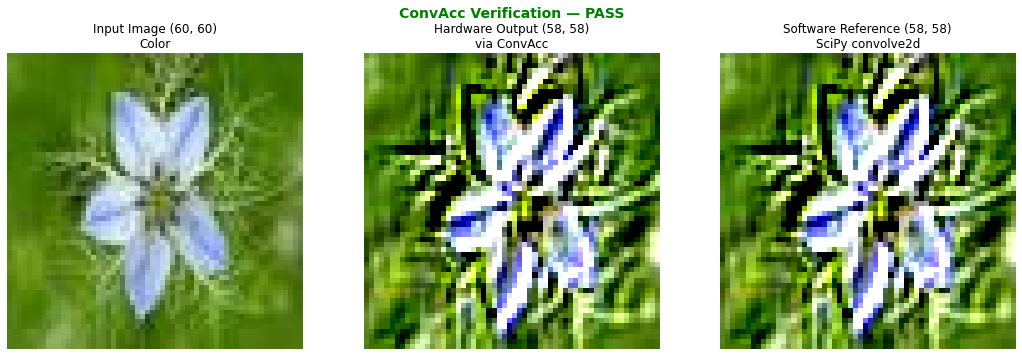

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Input
input_color = np.stack([R, G, B], axis=2)
axes[0].imshow(input_color)
axes[0].set_title(f'Input Image {input_color.shape[:2]}\nColor', fontsize=12)
axes[0].axis('off')

# Hardware Output
output_color = np.stack([
    output_image_R.astype(np.uint8),
    output_image_G.astype(np.uint8),
    output_image_B.astype(np.uint8)
], axis=2)
axes[1].imshow(output_color)
axes[1].set_title(f'Hardware Output {output_color.shape[:2]}\nvia ConvAcc', fontsize=12)
axes[1].axis('off')

# Software Reference
ref_color = np.stack([R_ref, G_ref, B_ref], axis=2)
axes[2].imshow(ref_color)
axes[2].set_title(f'Software Reference {ref_color.shape[:2]}\nSciPy convolve2d', fontsize=12)
axes[2].axis('off')

# Comparison
match  = np.array_equal(output_color, ref_color)
n_diff = int(np.sum(output_color != ref_color))
total  = output_color.size

fig.suptitle(
    f'ConvAcc Verification — {"PASS" if match else f"FAIL ({n_diff}/{total} values differ)"}',
    fontsize=14, fontweight='bold',
    color='green' if match else 'red'
)
plt.tight_layout()
plt.show()

# Large Image Example

## Large Image Example — tiling around the 60-pixel width limit

The accelerator's line-buffer holds **4 lanes × 60 columns**, so any single
frame must be **≤ 60 pixels wide**. To process a 512×512 image like Lenna,
we slice it into vertical strips of 60 columns, run each strip through the
accelerator independently, and stitch the outputs back together.

### Why a 2-pixel overlap?
A 3×3 valid-mode convolution loses 1 pixel on each side of every tile —
both vertically and horizontally. To make the stitched output **identical**
to a single big convolution, neighbouring tiles must **overlap by 2 columns**:

```
tile N:        [ col 0  col 1  col 2 … col 59 ]
tile N+1:                            [ col 58  col 59 … col 117 ]
                                        ↑↑
                                   shared 2 cols
output of tile N covers columns 0..57; output of tile N+1 covers 58..115; etc.
```

That's what `step = tile_w - overlap` (= 58) and the `out_W = W - overlap`
arithmetic in `tile_channel_wide` are doing. The right edge is **edge-padded**
with `np.pad(..., mode='edge')` so the last tile is always 60 wide.

> **Heads-up:** because every tile triggers a fresh `allocate` / `transfer` /
> `freebuffer` cycle, this approach is **not** the throughput-optimal way to
> handle large images — it's the *clarity-optimal* one. For real performance,
> you'd want a single large CMA pair plus one DMA descriptor per tile.

### Layout of this section (live-demo friendly)
The original monolithic cell has been **split into five cells** so each
stage runs separately during a live demo:

1. **Helpers** — define `run_channel_on_fpga` and `tile_channel_wide`.
2. **Load image** — open `Lenna.png` and split into R/G/B planes.
3. **FPGA pass** — tile + run all three channels through `convAcc`.
4. **scipy pass** — same convolution on the on-chip Arm Cortex-A9.
5. **Plot + verify** — 3-panel figure with PASS/FAIL.


In [45]:
# ── Helper functions for the tiled large-image flow ──────────────────────


def run_channel_on_fpga(channel_2d):
    """Send one 2D channel through convAcc, return (H-2, W-2) output."""
    h, w = channel_2d.shape
    cfg_words  = build_config(w, h, kernel)
    pixel_words = pack_pixels(channel_2d)
    all_beats  = cfg_words + pixel_words

    n_words_in  = len(all_beats)
    n_out_pixels = (h - 2) * (w - 2)
    n_out_words  = (n_out_pixels + 3) // 4

    send_buf = allocate(shape=(n_words_in,),      dtype=np.uint32)
    recv_buf = allocate(shape=(n_out_words + 8,), dtype=np.uint32)

    for i, w_val in enumerate(all_beats):
        send_buf[i] = w_val

    dma.sendchannel.start()
    dma.recvchannel.start()
    dma.recvchannel.transfer(recv_buf)
    dma.sendchannel.transfer(send_buf)
    dma.recvchannel.wait()
    dma.sendchannel.wait()

    raw_bytes = bytearray()
    for word in recv_buf[:n_out_words]:
        raw_bytes += struct.pack('<I', int(word))

    dma.sendchannel.stop()
    dma.recvchannel.stop()
    send_buf.freebuffer()
    recv_buf.freebuffer()

    return np.frombuffer(raw_bytes[:n_out_pixels], dtype=np.uint8).reshape(h - 2, w - 2)


def tile_channel_wide(channel_2d, tile_w=60, overlap=2):
    H, W  = channel_2d.shape
    step  = tile_w - overlap  


    out_W = W - overlap     
    n_tiles = (out_W + step - 1) // step  
  
    W_needed = (n_tiles - 1) * step + tile_w  
    pad_w = W_needed - W
    if pad_w > 0:
        channel_2d = np.pad(channel_2d, ((0, 0), (0, pad_w)), mode='edge')

    _, W_padded = channel_2d.shape
    out_H = H - overlap
    output = np.zeros((out_H, out_W), dtype=np.uint8)
    
    x  = 0
    ox = 0
    for tile_num in range(n_tiles):
        tile     = channel_2d[:, x:x + tile_w]
        tile_out = run_channel_on_fpga(tile)

        cols_to_write = min(tile_out.shape[1], out_W - ox)
        if cols_to_write <= 0:
            break

        output[:, ox:ox + cols_to_write] = tile_out[:, :cols_to_write]

        x  += step
        ox += cols_to_write


    return output


### Load Lenna and split into R / G / B planes

`Lenna.png` is a 512×512 RGB image. We split it into three 2-D `uint8`
arrays so each can be tiled and run through the accelerator independently.


In [46]:
img = Image.open("Lenna.png")
img_np = np.array(img, dtype=np.uint8)
H, W, C = img_np.shape
print(f"Image shape: {img_np.shape}")

R = img_np[:, :, 0]
G = img_np[:, :, 1]
B = img_np[:, :, 2]


Image shape: (250, 250, 3)


### FPGA pass — tiled convolution on `convAcc`  

Run all three channels through the tiler. Each channel is sliced into 60-wide
strips, each strip is sent over AXI-Stream to `convAcc`, and the per-tile
outputs are stitched into a full `(H-2) × (W-2)` plane.


In [47]:
# --- Process each channel ---

print("Processing R...")
R_out = tile_channel_wide(R)
print("Processing G...")
G_out = tile_channel_wide(G)
print("Processing B...")
B_out = tile_channel_wide(B)

# --- Merge and display ---
output_color = np.stack([R_out, G_out, B_out], axis=2)


Processing R...
Processing G...
Processing B...


### scipy reference — same convolution on the Arm Cortex-A9 

The Zynq's PS-side Arm Cortex-A9 runs the exact same 3×3 convolution via
`scipy.signal.convolve2d`. This is the apples-to-apples software baseline.

In [48]:

kernel_np = np.array(kernel, dtype=np.int32)

R_ref = np.clip(convolve2d(R.astype(np.int32), kernel_np, mode='valid'), 0, 255).astype(np.uint8)
G_ref = np.clip(convolve2d(G.astype(np.int32), kernel_np, mode='valid'), 0, 255).astype(np.uint8)
B_ref = np.clip(convolve2d(B.astype(np.int32), kernel_np, mode='valid'), 0, 255).astype(np.uint8)
ref_color = np.stack([R_ref, G_ref, B_ref], axis=2)


### Plot + verification

Stack the inputs, the FPGA output, and the scipy reference into a 3-panel
figure. The suptitle calls `np.array_equal` for the strict bit-exact pass/fail
check — this is the strongest correctness signal in the notebook because it
exercises **every** path: buffer reuse, repeated DMA cycles, right-edge
padding, and channel stitching.


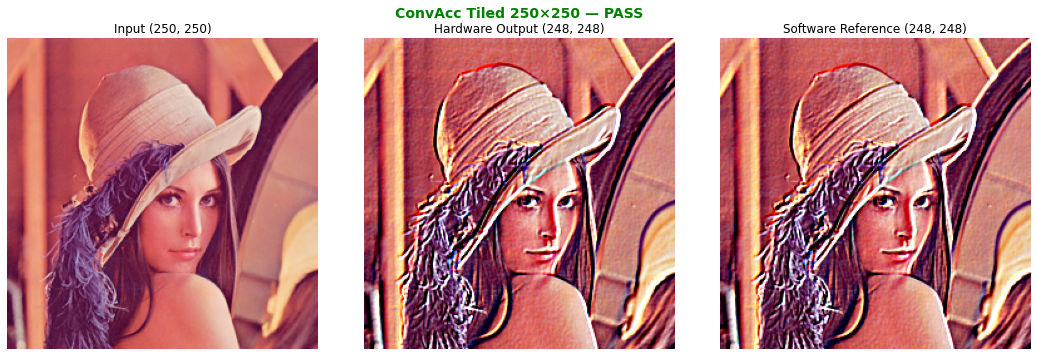

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np)
axes[0].set_title(f'Input {img_np.shape[:2]}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(output_color)
axes[1].set_title(f'Hardware Output {output_color.shape[:2]}', fontsize=12)
axes[1].axis('off')

axes[2].imshow(ref_color)
axes[2].set_title(f'Software Reference {ref_color.shape[:2]}', fontsize=12)
axes[2].axis('off')

match  = np.array_equal(output_color, ref_color)
n_diff = int(np.sum(output_color != ref_color))
fig.suptitle(
    f'ConvAcc Tiled 250×250 — {"PASS" if match else f"FAIL ({n_diff}/{output_color.size} values differ)"}',
    fontsize=14, fontweight='bold',
    color='green' if match else 'red'
)
plt.tight_layout()
plt.show()


## Where to go next

A few natural extensions for someone exploring this design:

- **Try a different kernel.** Swap the active `kernel` in the overlay cell
  for the Sobel-X (commented out at the top), a Gaussian blur, or a Laplacian
  edge detector. The pass/fail check at the bottom of each section will tell
  you immediately if the hardware still matches scipy.
- **Stress the timing comparison.** The large-image section measures one
  250x250 frame; for a more rigorous benchmark across thousands of random
  data points, see `Benchmark_Arm_and_Acclerator_after_implimentation.ipynb` in
  this repo.
- **Push the size.** The largest single-shot frame the design supports is
  60 × 1023. The tiling helper handles wider; what about taller? (Hint: the
  height limit comes from `num_rows[15:6]` in the config word.)
- **Read the RTL.** The verilog files for the IP live alongside this notebook —
  start with `convAcc.sv` for the top, then drill into `lineBuffer.sv` and
  `mac_truncate.sv` for the data-path, and `busInterfaceUnit.sv` / `cf_mem.sv`
  for the AXI-Stream front-end.
